# Deepforest - Training


In [ ]:
#install the necessary packages
%pip install --upgrade deepforest
%pip install geojson


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 20.0 MB 1.2 MB/s 
     |████████████████████████████████| 1.0 MB 52.5 MB/s 
     |████████████████████████████████| 19.3 MB 1.2 MB/s 
     |████████████████████████████████| 31.0 MB 13.6 MB/s 
     |████████████████████████████████| 1.0 MB 51.8 MB/s 
     |████████████████████████████████| 707 kB 57.7 MB/s 
     |████████████████████████████████| 16.7 MB 36.0 MB/s 
     |████████████████████████████████| 6.3 MB 49.4 MB/s 
     |████████████████████████████████| 5.9 MB 45.2 MB/s 
     |████████████████████████████████| 419 kB 52.5 MB/s 
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.8.0
    Uninstalling tensorboard-2.8.0:
      Successfully uninstalled tensorboard-2.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

In [ ]:
#load the necessary libraries
import os
import time
import numpy as np
from deepforest import main
from deepforest import get_data
from deepforest import utilities
from deepforest import preprocess
from deepforest import evaluate
from google.colab import drive
import json
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import cv2
from os import listdir
from os.path import isfile, join
import pandas as pd
import geojson
from sklearn.model_selection import train_test_split
import rasterio as rio
from PIL import Image
import deepforest

In [ ]:
#mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# getting the names of all the tiles in the 2019 folder
my_path = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/' 
onlyfiles2021 =  listdir(my_path)
len(onlyfiles2021)

21

In [ ]:
# getting the names of all the tiles in the 2021 folder
my_path = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/' 
onlyfiles2019 =  listdir(my_path)
len(onlyfiles2019)

19

In [ ]:
# Splitting the image paths in validation, train and test paths according to the default lists
# Every dataframe is composed by a list of patches to the tif image

defaultTest = ['L18', 'C13', 'T31', 'M20', 'M12', 'T1', 'N3']

testPaths = pd.DataFrame(defaultTest)

testPaths = testPaths+'.tif'

testPaths[testPaths.isin(onlyfiles2019)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/'+testPaths[testPaths.isin(onlyfiles2019)] 
testPaths[testPaths.isin(onlyfiles2021)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/'+testPaths[testPaths.isin(onlyfiles2021)] 


defaultValidation = pd.DataFrame(['ZK12', 'ZK17', 'C10', 'ZB2', 'ZK16', 'T5', 'T40', 'ZK10'])

validationPaths = pd.DataFrame(defaultValidation)

validationPaths = validationPaths+'.tif'

validationPaths[validationPaths.isin(onlyfiles2019)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/'+validationPaths[validationPaths.isin(onlyfiles2019)]
validationPaths[validationPaths.isin(onlyfiles2021)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/'+validationPaths[validationPaths.isin(onlyfiles2021)]



# The default train list is composed by the remaining tiles

defaultTrain = pd.DataFrame(['ZK14', 'T74', 'C9', 'ZK11', 'ZB3', 'ZB1', 'L16', 'T37', 'ZK15',
       'T34', 'T9', 'M10', 'ZK7', 'M1', 'ZK21', 'C12', 'ZK18', 'T66',
       'ZK13', 'ZK9', 'C14', 'T7', 'T63', 'N13'])

trainPaths = pd.DataFrame(defaultTrain)

trainPaths = trainPaths+'.tif'

trainPaths[trainPaths.isin(onlyfiles2019)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/'+trainPaths[trainPaths.isin(onlyfiles2019)]
trainPaths[trainPaths.isin(onlyfiles2021)] = '/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/'+trainPaths[trainPaths.isin(onlyfiles2021)]

# Checking that the dataframes are mutually exclusive
if pd.concat((trainPaths,validationPaths,testPaths)).nunique()[0]!=(trainPaths.shape[0]+validationPaths.shape[0]+testPaths.shape[0]):
  raise Exception()



In [ ]:
# Function to get the geojson label for one image and transform them to bounding boxes

# the input is simply the name of the tile without any extension as a string
def getTilesLabels(tileName):
  # get the path to the annotations for this image
  path_to_file = '/content/drive/MyDrive/Trees-sub-rgb'+'/labels/' + tileName + '.geojson' 

  # open the annotation file for this image
  with open(path_to_file) as f:
    gj = geojson.load(f)

  # extract relevant info from the file
  gjName = gj['name']
  gjFeatures = gj['features']
  gjType = gj['type']

  # create dataframe to store the transformed annotations
  labelsFile = pd.DataFrame()

  # for every shape (polygon) in the annotation file, obtain the:
  # - minimum and maximum latituted and longitude
  # - the image path

  for gjFi in gjFeatures:
    # check that the shape is not empty
    if gjFi['geometry']!=None and gjFi['geometry']['coordinates']!=[]:
      # extract the min max coordinates
     coord =  np.array(gjFi['geometry']['coordinates'][0])
     latmin = coord[:,0].min()
     latmax = coord[:,0].max()
     longmin = coord[:,1].min()
     longmax = coord[:,1].max()
     # add extracted info to the df
     labelsFile =labelsFile.append({'latmin':latmin, 'longmin':longmin, 'latmax':latmax, 'longmax':longmax }, ignore_index = True)

  return labelsFile

In [ ]:
# Function to apply the getTilesLabels() function to a list of paths, merge the annotations in one dataframe and
# apply some futher modification to the annotations

# The input is the dataframe that were created in the section 1.1 of this notebook
def pathsToFormattedDf(pathDf):

  # create empty df to collect the results
  formattedDf = pd.DataFrame()

  # for ever image in the input dataframe
  for i in pathDf.iloc[:,0]:
      # get the tile/image name
      tileName = i.replace('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/', '')
      tileName = tileName.replace('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/', '')
      tileName = tileName.replace('.tif', '')

      # use the getTilesLabels function
      annotations = getTilesLabels(tileName)

      # Get the coordinates data for the image
      imgDataset = rio.open(i)

      # Trasnforms coordinates to pixels and invert min and max for the latitude
      annotations.loc[:,'ymax'], annotations.loc[:,'xmin'] =  rio.transform.rowcol(imgDataset.transform,annotations.latmin, annotations.longmin )
      annotations.loc[:,'ymin'], annotations.loc[:,'xmax'] =  rio.transform.rowcol(imgDataset.transform,annotations.latmax, annotations.longmax )

      # add the tile name with the extensions
      annotations.loc[:,'image_path'] = tileName+'.tif'

      # add a proxy as a label
      annotations.loc[:,'label'] = 'Tree'

      # append the new annotations to the result file
      formattedDf = formattedDf.append(annotations, ignore_index= True)

  # output the results
  return formattedDf[['image_path', 'xmin', 'ymin', 'xmax', 'ymax', 'label']]


In [ ]:
# apply the pathsToFormattedDf function to the train paths
# drop duplicates
# reset index
# save the results

trainDf = pathsToFormattedDf(trainPaths)
print('We drop', trainDf.duplicated().sum(),'duplicates')
trainDf = trainDf.drop_duplicates()
trainDf = trainDf.reset_index(drop=True)


print('shape:',trainDf.shape)
trainDf.to_csv('trainDf.csv',index=False)

We drop 4 duplicates
shape: (9373, 6)


In [ ]:
# apply the pathsToFormattedDf function to the validation paths
# drop duplicates
# reset index
# save the results

validationDf = pathsToFormattedDf(validationPaths)
print('We drop', validationDf.duplicated().sum(),'duplicates')
validationDf = validationDf.drop_duplicates()
validationDf = validationDf.reset_index(drop=True).copy()

print('shape:',validationDf.shape)
validationDf.to_csv('validationDf.csv',index=False)

We drop 0 duplicates
shape: (3563, 6)


In [ ]:
# apply the pathsToFormattedDf function to the test paths
# drop duplicates
# reset index
# save the results

testDf = pathsToFormattedDf(testPaths)
print('We drop', testDf.duplicated().sum(),'duplicates')
testDf = testDf.drop_duplicates()
testDf = testDf.reset_index(drop=True)

print('shape:',testDf.shape)
testDf.to_csv('testDf.csv',index=False)

We drop 6 duplicates
shape: (3136, 6)


In [ ]:
# get the default pretrained  deepforest model
m = main.deepforest()
m.use_release()

Reading config file: /usr/local/lib/python3.7/dist-packages/deepforest/data/deepforest_config.yml


/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model from DeepForest release https://github.com/weecology/DeepForest/releases/tag/1.0.0 was already downloaded. Loading model from file.
Loading pre-built model: https://github.com/weecology/DeepForest/releases/tag/1.0.0


In [ ]:
# function that gets a file path and an annotation df and plot the image with its annotations

def plotTileWithAnnotation(filepath, df):
  # get the name of the image
  tile_name = filepath.replace('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/', '').replace('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/', '') 

  # get the annotations for the image
  df2 = df[df['image_path'] == tile_name]
  print(df2.shape)

  # open the image and plot it
  im = np.array(Image.open(filepath))
  plt.figure(figsize=(12,16))

  # plot the annotations over the image
  ax = plt.gca()
  for idx, row in df2.iterrows():
        x1 = row['xmin']
        y1 = row['ymin']

        width = row['xmax']-row['xmin']
        height = row['ymax']-row['ymin']

        #create the rectangle object and add it to the image
        rect = Rectangle((x1,y1),  width, height, fill=False, color='red')
        ax.add_patch(rect)

  # show the plot
  plt.axis('off')
  plt.imshow(im)
  plt.show()


In [ ]:
# preduct tile with the default out of the box function
predicted_tile  = m.predict_tile(raster_path=validationPaths.iloc[0,0],
              patch_size=400, patch_overlap=0.05,
             iou_threshold=0.15, return_plot=True, mosaic=True, use_soft_nms=False, sigma=0.5, thresh=0.001, color=None, thickness=10)

100%|██████████| 12/12 [00:01<00:00,  9.96it/s]


319 predictions in overlapping windows, applying non-max supression
169 predictions kept after non-max suppression


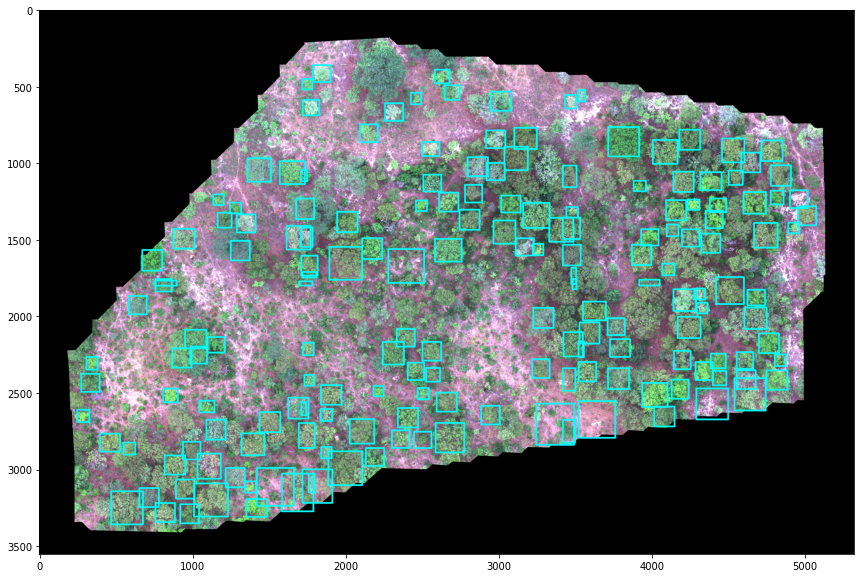

In [ ]:
# plot the predicctions
plt.figure(figsize=(20,10))
plt.imshow(predicted_tile[:,:,::-1])

(707, 6)


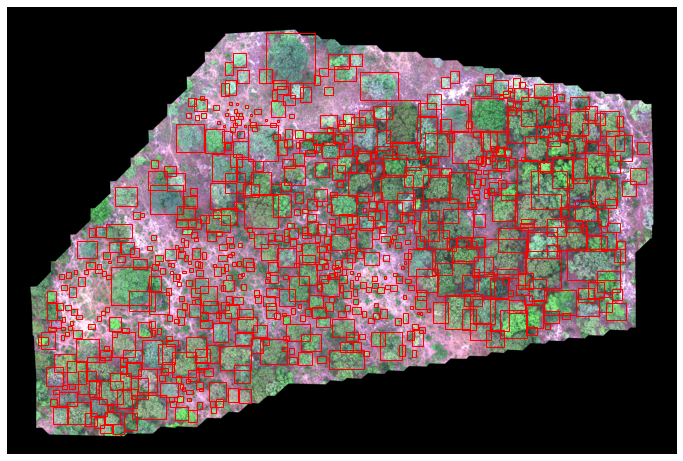

In [ ]:
# plot the ground truth
plotTileWithAnnotation( filepath = validationPaths.iloc[0,0], df= validationDf)

In [ ]:
# function that evaluates list of tiles and computes the weighted average of the default evaluation metrics as the
# precision, recall and F1 score

# a model m

def evaluateSetOfTIles(m, list_of_tiles, annotation_file, patch_size=400):

  # create some dummies
  true_positive = 0
  true_negative = 0
  false_positive = 0
  false_positive = 0
  number_of_labels = 0
  number_of_predictions = 0
  weird_matches = 0

  # create temporary folder to store the cropped images
  os.path.join(os.getcwd(),'train_data_folder')
  crop_dir = os.path.join(os.getcwd(),'train_data_folder')

  # For every image path in the list
  for i in list_of_tiles:
    # crop the annotations and images in smaller patches
    output_annotations = deepforest.preprocess.split_raster(path_to_raster = i,
                                                            annotations_file = annotation_file, base_dir = crop_dir, patch_size = patch_size)
    # save the cropped annotations temporarily
    output_annotations.to_csv("cropped_annotations.csv")

    # evaluate the model predictions on the cropped annotations file
    results = m.evaluate(csv_file="cropped_annotations.csv",
                           root_dir=crop_dir)

    # compute number of true positive and number or predictions
    number_of_labels += results['results'].shape[0]
    number_of_predictions += results['predictions'].shape[0]
    true_positive += results['results'].match.sum()
    weird_matches += results['results'].match.isna().sum()

    # remove the temporary files
    %rm -rf train_data_folder


  # compute the weighted average of the metrics
  recall = true_positive / number_of_labels
  precision = true_positive / number_of_predictions
  res = {'number_of_labels':number_of_labels, 'number_of_predictions':number_of_predictions,
         'true_positive':true_positive, 'recall':recall, 'precision':precision, 'F1':(2*precision*recall)/(precision+recall), 'weird_matches':weird_matches}

  return res

In [ ]:
# list of patches to evaluate
interesting_patch_sizes =[400,600,800,1000,1200,1400,1600,1700,1800,1900,2000,2100]

# temp dataframe to save the results
dfPatchEval = pd.DataFrame()

# Evalaute model for different patch sizes with the function above
# Store the results in the dataframe
for i in interesting_patch_sizes:
  valI = evaluateSetOfTIles(m, validationPaths.iloc[:,0], "validationDf.csv", patch_size=i)
  valI['patchSize'] = i
  dfPatchEval = dfPatchEval.append(valI,ignore_index=True)

In [ ]:
# plot the results
dfPatchEval.plot(x='patchSize', y=['precision','recall', 'F1'], figsize=(10,5))

In [ ]:
# show the dataframe
dfPatchEval

The image below shows the results as obtained by us during the training and as reported in the report.

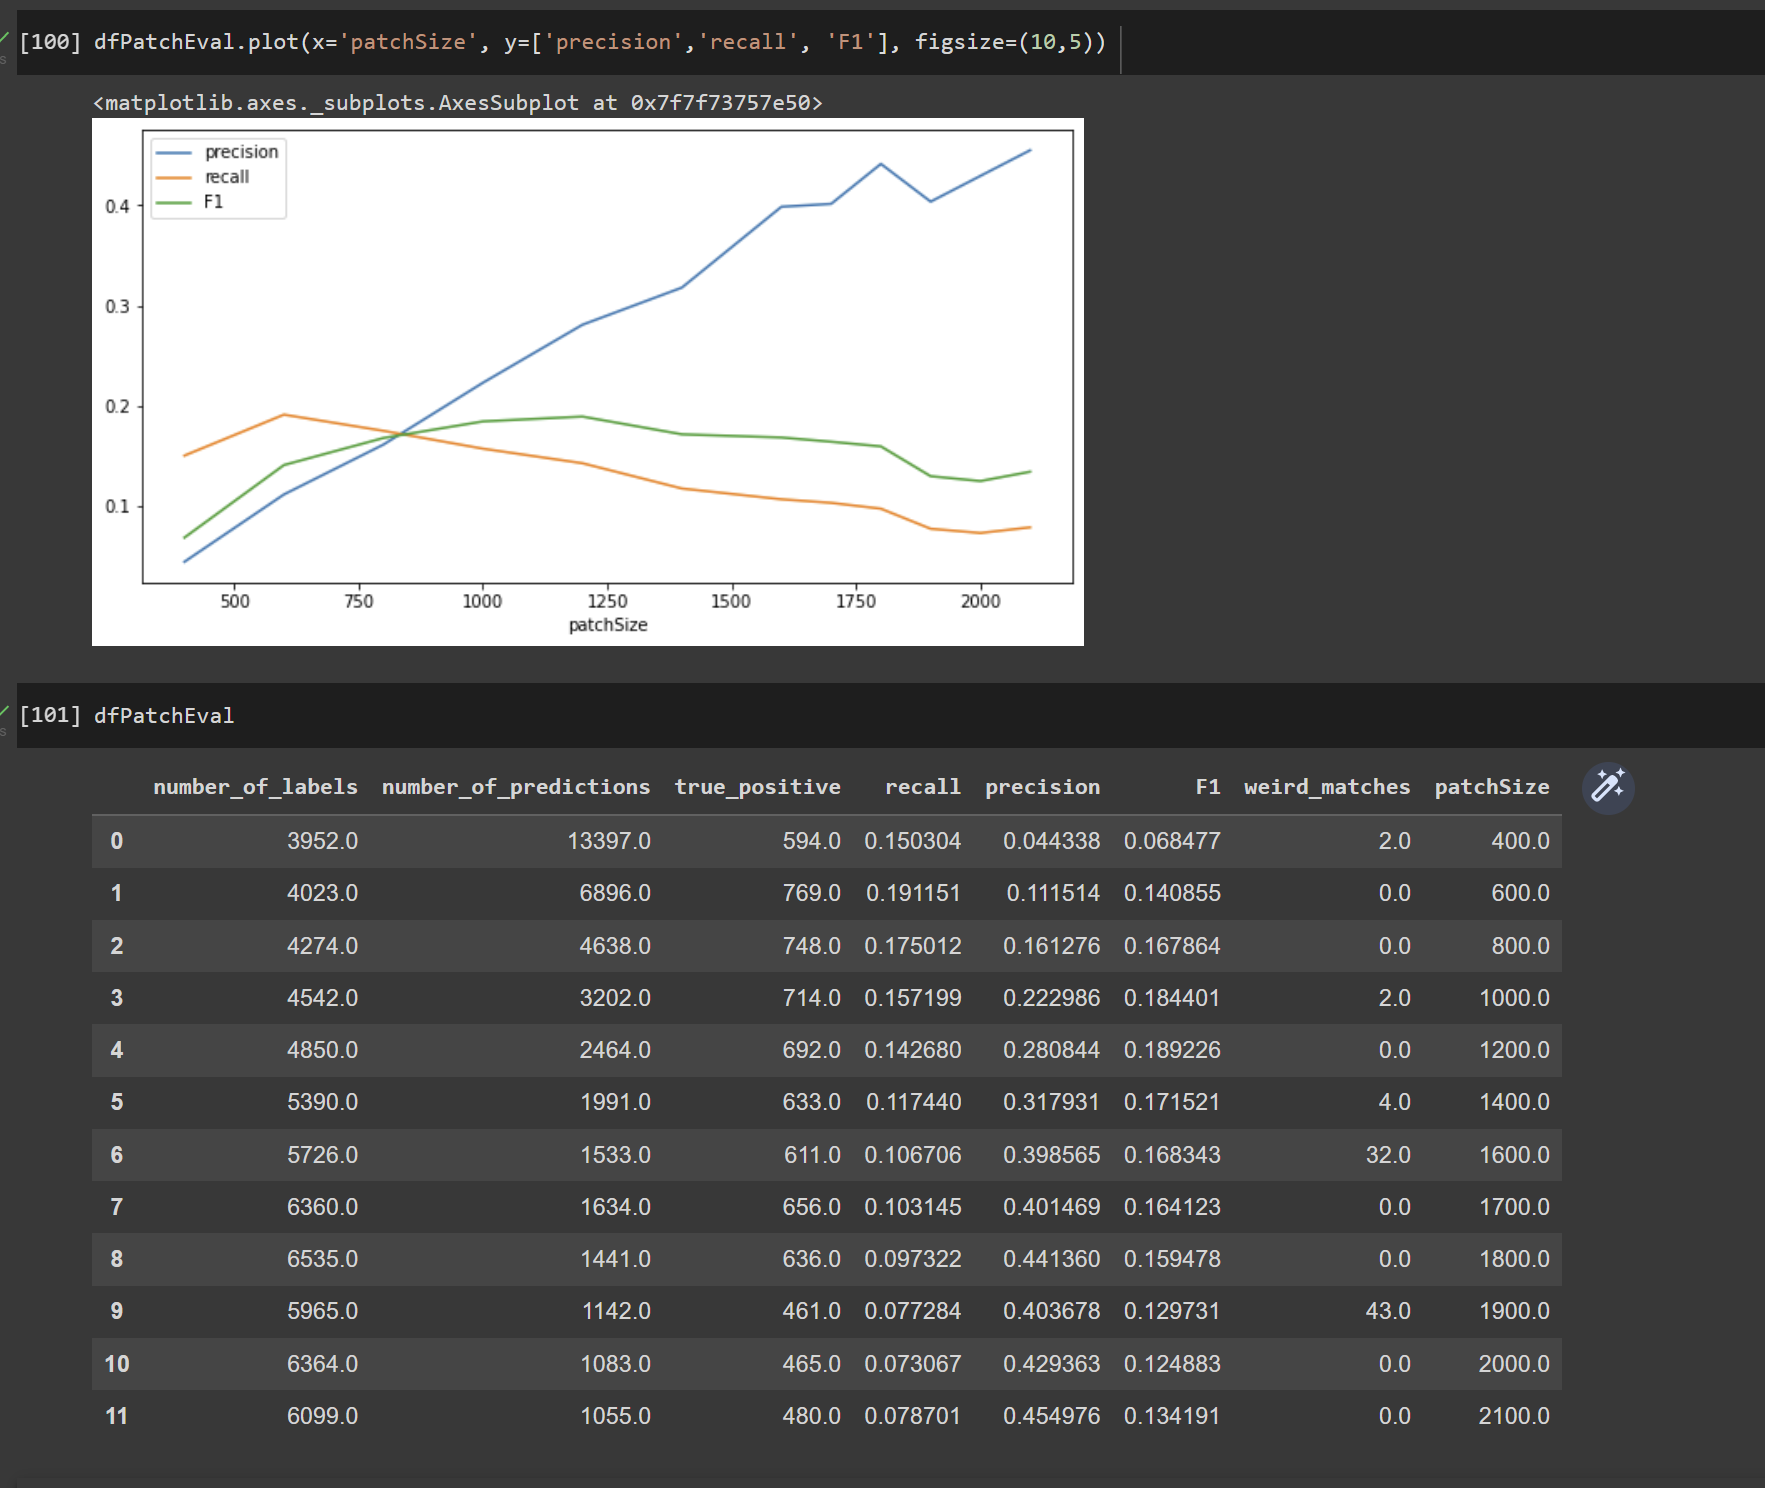

In [ ]:
# function to crop validation data in a desired patch size and save them
def preprocessValData(patch_size):
  # create temporary folder
  os.path.join(os.getcwd(),'validation_data_folder')
  crop_dir_val = os.path.join(os.getcwd(),'validation_data_folder')
  # remove content of the folder if any
  !rm -rf validation_data_folder

  # create validation annotation file for the cropped images
  validation_output_annotations = pd.DataFrame()

  # crop all the validation images one by one
  for i in validationPaths.iloc[:,0]:

    output_annotations = deepforest.preprocess.split_raster(path_to_raster = i,
                                                            annotations_file = "validationDf.csv",
                                                            base_dir = crop_dir_val,
                                                            patch_size = patch_size)
    # add cropped annotations to the same file
    validation_output_annotations = pd.concat([validation_output_annotations,output_annotations],ignore_index=True)

  # temporarily save the annotation file
  validation_output_annotations.to_csv("validation_cropped_annotations.csv")

  # output the path to the cropped annotations
  return crop_dir_val

In [ ]:
# import the pretrained-model
m = main.deepforest()
m.use_release()

# create df to store results
patchEval = pd.DataFrame()

# evaluate the model on the validation data for different patch sizes
for i in [400,600,800,1000,1200,1400,1600,1700,1800,1900,2000,2100]:
  crop_dir_val = preprocessValData(i)
  res = m.evaluate(csv_file='validation_cropped_annotations.csv',
                           root_dir=crop_dir_val)
  # add results to the file
  patchEval = patchEval.append({'patch_size':i, 'box_precision':res['box_precision'],'box_recall':res['box_recall']}, ignore_index=True)

In [ ]:
# plot results
patchEval.loc[:,'F1_score'] = (2*patchEval.box_precision*patchEval.box_recall)/(patchEval.box_precision+patchEval.box_recall)

The image summarizes the results obtained with the approach. They are similar to the other ones but these ones were not used in the report.

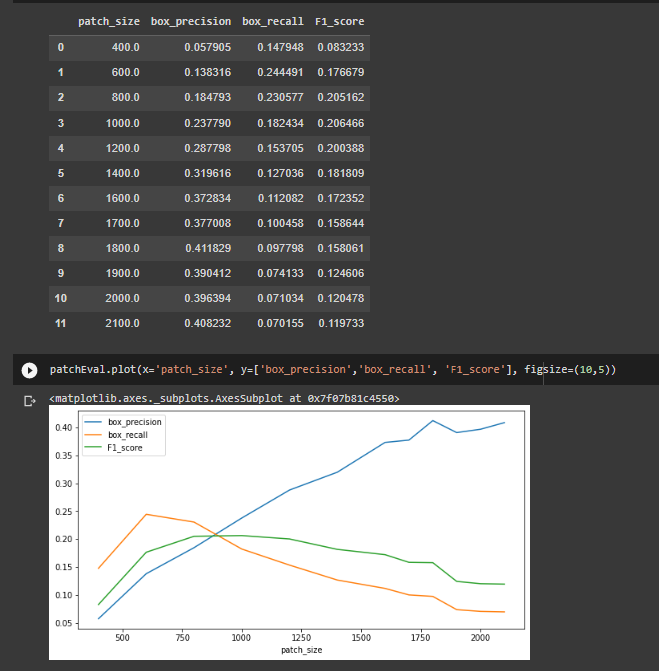

In [ ]:
# function to crop validation and train data to a certain patch size
def preprocessData(patch_size):
  # create temporary folder
  os.path.join(os.getcwd(),'train_data_folder')
  crop_dir = os.path.join(os.getcwd(),'train_data_folder')
  # remove content of the folder if any
  %rm -rf train_data_folder

  # create train annotation file for the cropped images
  train_output_annotations = pd.DataFrame()

  # crop all the train images one by one
  for i in trainPaths.iloc[:,0]:

    output_annotations = deepforest.preprocess.split_raster(path_to_raster = i,
                                                            annotations_file = "trainDf.csv",
                                                            base_dir = crop_dir,
                                                            patch_size = patch_size)
    # add cropped annotations to the same file
    train_output_annotations = pd.concat([train_output_annotations,output_annotations],ignore_index=True)

  # temporarily save the annotation file
  train_output_annotations.to_csv("train_cropped_annotations.csv")

  # create temporary folder
  os.path.join(os.getcwd(),'validation_data_folder')
  crop_dir_val = os.path.join(os.getcwd(),'validation_data_folder')
  # remove content of the folder if any
  %rm -rf validation_data_folder
  # create validation annotation file for the cropped images
  validation_output_annotations = pd.DataFrame()

  # crop all the validation images one by one
  for i in validationPaths.iloc[:,0]:

    output_annotations = deepforest.preprocess.split_raster(path_to_raster = i,
                                                            annotations_file = "validationDf.csv",
                                                            base_dir = crop_dir_val,
                                                            patch_size = patch_size)
    # add cropped annotations to the same file
    validation_output_annotations = pd.concat([validation_output_annotations,output_annotations],ignore_index=True)

  # temporarily save the annotation file
  validation_output_annotations.to_csv("validation_cropped_annotations.csv")

  # output the path to the cropped annotations
  return crop_dir, crop_dir_val

In [ ]:
# test the function above
trained_model = runWABExperiment(
    patch_size=1200,
    lr=0.001,
    epochs=5,
    batch_size=5,
    preload_images=False,
    fast_dev_run=False
)

In [ ]:
best600Run = 'valiant-dew-10val_bbox_regression-epoch=06-val_bbox_regression=0.39.ckpt'
library_path = '/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/model_library/'
# load model
m600 = main.deepforest.load_from_checkpoint(library_path+best600Run)

# create patches
crop_dir, crop_dir_val = preprocessData(600)

# evaluate with different treshholds
# and store the results in this empty dataset
m600Curve = pd.DataFrame()

for i in [0.1,0.2,0.3,0.4,0.5,0.6,0.9]:
  m600.config['score_thresh'] = i
  res = m600.evaluate(csv_file='validation_cropped_annotations.csv',
                           root_dir=crop_dir_val)
  m600Curve = m600Curve.append({'score_thresh':i, 'box_precision':res['box_precision'],'box_recall':res['box_recall']}, ignore_index=True)

Reading config file: /usr/local/lib/python3.7/dist-packages/deepforest/data/deepforest_config.yml


/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

No predictions made


/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/usr/local/lib/python3.7/dist-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [ ]:
best1200Run = "crimson-wood-16val_bbox_regression-epoch=08-val_bbox_regression=0.45.ckpt"
library_path = '/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/model_library/'#<--change this path according to your drive configuration (where is the folder containing best model in yur drive?)
# load model
m1200 = main.deepforest.load_from_checkpoint(library_path+best1200Run)

# create patches
crop_dir, crop_dir_val = preprocessData(1200)

# evaluate with different treshholds

m1200Curve = pd.DataFrame()
# and store the results in this empty dataset
for i in [0.1,0.2,0.3,0.4,0.5,0.6,0.9]:
  m1200.config['score_thresh'] = i
  res = m1200.evaluate(csv_file='validation_cropped_annotations.csv',
                           root_dir=crop_dir_val)
  m1200Curve = m1200Curve.append({'score_thresh':i, 'box_precision':res['box_precision'],'box_recall':res['box_recall']}, ignore_index=True)

Reading config file: /usr/local/lib/python3.7/dist-packages/deepforest/data/deepforest_config.yml


/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [ ]:
# save the two dataframes with the precision recalls curve
m600Curve.to_pickle('/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/m600Curve')
m1200Curve.to_pickle('/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/m1200Curve') 

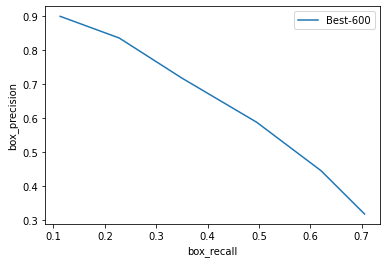

In [ ]:
# plot the M660 curve
ax = m600Curve.plot(y='box_precision',x='box_recall',label='Best-600')
ax.set_ylabel('box_precision')
ax.figure.savefig('/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/precision_recall_curve',bbox_inches='tight')  #<--change this path according to your drive configuration

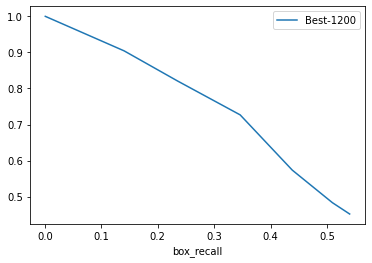

In [ ]:
# plot the m1200 curve
m1200Curve.plot(y='box_precision',x='box_recall',label='Best-1200')

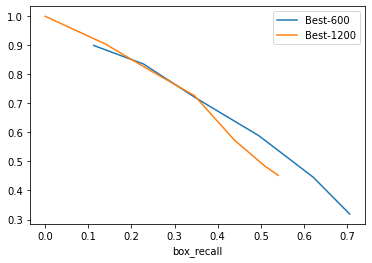

In [ ]:
# plot the curves together
ax = m600Curve.plot(y='box_precision',x='box_recall',label='Best-600')
m1200Curve.plot(y='box_precision',x='box_recall',label='Best-1200',ax=ax)

In [ ]:
# compute the F1 score for the 2 curves
m600Curve.loc[:,'f1_score'] = (2*m600Curve.box_precision*m600Curve.box_recall)/(m600Curve.box_precision+m600Curve.box_recall)
m1200Curve.loc[:,'f1_score'] = (2*m1200Curve.box_precision*m1200Curve.box_recall)/(m1200Curve.box_precision+m1200Curve.box_recall)

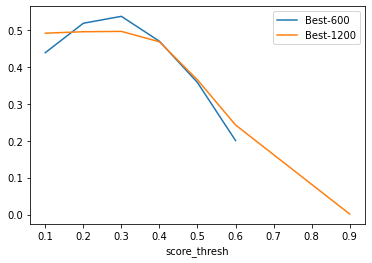

In [ ]:
# plot the F1 scores
ax = m600Curve.plot(y='f1_score',x='score_thresh',label='Best-600')
m1200Curve.plot(y='f1_score',x='score_thresh',label='Best-1200',ax=ax)

In [ ]:
m600Curve

,score_thresh,box_precision,box_recall,f1_score
0,0.1,0.319001,0.705637,0.439373
1,0.2,0.446227,0.620880,0.519261
2,0.3,0.588775,0.495329,0.538025
3,0.4,0.718579,0.349583,0.470346
4,0.5,0.835813,0.228086,0.358374
5,0.6,0.899554,0.113064,0.200880
6,0.9,NaN,0.000000,NaN


In [ ]:
m1200Curve

,score_thresh,box_precision,box_recall,f1_score
0,0.1,0.452104,0.540285,0.492277
1,0.2,0.483461,0.509741,0.496253
2,0.3,0.573742,0.438574,0.497134
3,0.4,0.726891,0.346153,0.468975
4,0.5,0.820813,0.235171,0.365595
5,0.6,0.904281,0.140496,0.243206
6,0.9,1.000000,0.000716,0.001431


In [ ]:
best600Run = 'valiant-dew-10val_bbox_regression-epoch=06-val_bbox_regression=0.39.ckpt'
library_path = '/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/model_library/'
# load model the best model
m600 = main.deepforest.load_from_checkpoint(library_path+best600Run)

# set the optimal thrsehold score
m600.config['score_thresh'] = 0.3

# create a df with the img name path as index and the number of labels as a column
MSE600 = pd.DataFrame(validationDf.image_path.value_counts())

# compute the number of predictions for every tile
for i in validationPaths.iloc[:,0]:
  print(i)
  res = m600.predict_tile(raster_path=i,
             #, image = Image.open(raster_path)
              patch_size=600, patch_overlap=0.05,
             iou_threshold=0.15, return_plot=False, mosaic=True, use_soft_nms=False, sigma=0.5, color=None, thickness=10)

  MSE600.loc[('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/'+MSE600.index == i)|('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/'+MSE600.index == i),'predicted'] =  res.shape[0] 

Reading config file: /usr/local/lib/python3.7/dist-packages/deepforest/data/deepforest_config.yml


/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/ZK12.tif


100%|██████████| 70/70 [00:03<00:00, 18.73it/s]


681 predictions in overlapping windows, applying non-max supression
571 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/ZK17.tif


...

263 predictions in overlapping windows, applying non-max supression
217 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/T40.tif


100%|██████████| 72/72 [00:04<00:00, 17.46it/s]


72 predictions in overlapping windows, applying non-max supression
64 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/ZK10.tif


100%|██████████| 56/56 [00:03<00:00, 17.41it/s]

663 predictions in overlapping windows, applying non-max supression
555 predictions kept after non-max suppression


In [ ]:
# compute the RMSE
np.sqrt(((MSE600.image_path-MSE600.predicted)**2).sum()/MSE600.shape[0])

175.9570260035103

In [ ]:
# Compute the MAPE
(abs(MSE600.predicted-MSE600.image_path)/MSE600.image_path).sum()/MSE600.shape[0]

0.26808378269438626

Create correct annotations for test set

In [ ]:
# create correct annotations for test set
# create temporary folder
os.path.join(os.getcwd(),'test_data_folder')
crop_dir_test = os.path.join(os.getcwd(),'test_data_folder')
# remove folder content if ay
!rm -rf test_data_folder
test_output_annotations = pd.DataFrame()
patch_size = 600
# create cropped test data with patch size of 600
for i in testPaths.iloc[:,0]:

    output_annotations = deepforest.preprocess.split_raster(path_to_raster = i,
                                                            annotations_file = "testDf.csv",
                                                            base_dir = crop_dir,
                                                            patch_size = patch_size)

    test_output_annotations = pd.concat([test_output_annotations,output_annotations],ignore_index=True)

# save the cropped annotations
test_output_annotations.to_csv("test_cropped_annotations.csv")



/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value
/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [ ]:
# load best model
best600Run = 'valiant-dew-10val_bbox_regression-epoch=06-val_bbox_regression=0.39.ckpt'
library_path = '/content/drive/MyDrive/Trees-sub-rgb/Google colab notebooks/deepforest/model_library/'#<--change this path according to your drive configuration (where is the folder containing best model in yur drive?)
# load model
m600 = main.deepforest.load_from_checkpoint(library_path+best600Run)

m600.config['score_thresh'] = 0.3


Reading config file: /usr/local/lib/python3.7/dist-packages/deepforest/data/deepforest_config.yml


/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# evaluate model on the test set see metrics below
res = m600.evaluate(csv_file='test_cropped_annotations.csv',
                           root_dir=crop_dir_test)

In [ ]:
res['box_precision']

In [ ]:
res['box_recall']

In [ ]:
(res['box_precision']*res['box_recall']*2)/(res['box_precision']+res['box_recall'])

In [ ]:
# create a df with the img name path as index and the number of labels as a column
MSE600TEST = pd.DataFrame(testDf.image_path.value_counts())

# Use predict tile to get number of predictions per tile
for i in testPaths.iloc[:,0]:
  print(i)
  res = m600.predict_tile(raster_path=i,
             #, image = Image.open(raster_path)
              patch_size=600, patch_overlap=0.05,
             iou_threshold=0.15, return_plot=False, mosaic=True, use_soft_nms=False, sigma=0.5, color=None, thickness=10, thresh=0.3)
  MSE600TEST.loc[('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/'+MSE600TEST.index == i)|('/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/'+MSE600TEST.index == i),'predicted'] =  res.shape[0] #<--change this path according to your drive configuration

/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/C11.tif


100%|██████████| 56/56 [00:02<00:00, 19.37it/s]


789 predictions in overlapping windows, applying non-max supression
658 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/L18.tif


100%|██████████| 63/63 [00:03<00:00, 19.85it/s]


141 predictions in overlapping windows, applying non-max supression
128 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2021/img_tif_three_channels/C13.tif


...

113 predictions in overlapping windows, applying non-max supression
92 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/T1.tif


100%|██████████| 24/24 [00:01<00:00, 19.16it/s]


342 predictions in overlapping windows, applying non-max supression
231 predictions kept after non-max suppression
/content/drive/MyDrive/Trees-sub-rgb/01. Data/2019/img_tif_three_channels/N3.tif


100%|██████████| 64/64 [00:03<00:00, 19.63it/s]

480 predictions in overlapping windows, applying non-max supression
413 predictions kept after non-max suppression


In [ ]:
# RMSE
np.sqrt(((MSE600TEST.image_path-MSE600TEST.predicted)**2).sum()/MSE600TEST.shape[0])

In [ ]:
# MAPE
(abs(MSE600TEST.predicted-MSE600TEST.image_path)/MSE600TEST.image_path).sum()/MSE600TEST.shape[0]